# 02: Measure LLM Efficiency

## 1. Imports

In [1]:
import gc
# import os
# CACHE_PATH = '<path_to_cache>'
# os.environ["TORCH_HOME"] = CACHE_PATH
# os.environ["HF_HOME"] = CACHE_PATH
# os.environ["HUGGINGFACE_HUB_CACHE"] = CACHE_PATH
# os.environ["HUGGINGFACE_ASSETS_CACHE"] = CACHE_PATH
# os.environ["TRANSFORMERS_CACHE"] = CACHE_PATH

import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
# from huggingface_hub import login; login(token="<hf_token>")

from pruna.data.pruna_datamodule import PrunaDataModule
from pruna.evaluation.evaluation_agent import EvaluationAgent
from pruna.evaluation.metrics import (
    TotalTimeMetric,
    EnergyConsumedMetric,
    DiskMemoryMetric,
    TrainingMemoryMetric,
    InferenceMemoryMetric,
    TotalParamsMetric,
    TotalMACsMetric,
    TorchMetricWrapper,
)
from pruna.evaluation.task import Task

Multiple distributions found for package optimum. Picked distribution: optimum


## 1. Load the LLM

First, load one LLM. There is a list of preselected LLMs with small size. Feel free to try other models until the GPU memory is not enough!

In [2]:
model_ids = [
    "facebook/opt-125m",
    "facebook/opt-350m",
    "facebook/opt-1.3b",
    "facebook/opt-2.7b",
    # "meta-llama/Llama-3.2-1B",
    # "meta-llama/Llama-3.2-1B-Instruct",
    # "meta-llama/Llama-3.2-3B-Instruct", # requires authentication
    # "google/gemma-3-1b-it",
    # "google/gemma-3-4b-it",
    # "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    # "microsoft/Phi-4-mini-instruct",
    # "HuggingFaceTB/SmolLM-135M",
    # "HuggingFaceTB/SmolLM-135M-instruct",
    # "HuggingFaceTB/SmolLM-360M",
    # "HuggingFaceTB/SmolLM-360M-Instruct",
    # "HuggingFaceTB/SmolLM-1.7B",
    # "HuggingFaceTB/SmolLM-1.7B-Instruct",
    # "HuggingFaceTB/SmolLM2-135M",
    # "HuggingFaceTB/SmolLM2-135M-Instruct",
    # "HuggingFaceTB/SmolLM2-360M",
    # "HuggingFaceTB/SmolLM2-360M-Instruct",
    # "HuggingFaceTB/SmolLM2-1.7B",
    # "HuggingFaceTB/SmolLM2-1.7B-Instruct",
    # "PleIAs/Pleias-350m-Preview",
    # "PleIAs/Pleias-Pico",
    # "PleIAs/Pleias-1.2b-Preview",
    # "PleIAs/Pleias-Nano",
    # "PleIAs/Pleias-3b-Preview",
]

## 2. Utils

The utils functions help for:
- Load from a list of (small) models. Feel free to try other models until the GPU memory is not enough!
- Make plots.
- Iterate over evaluation and model configurations.

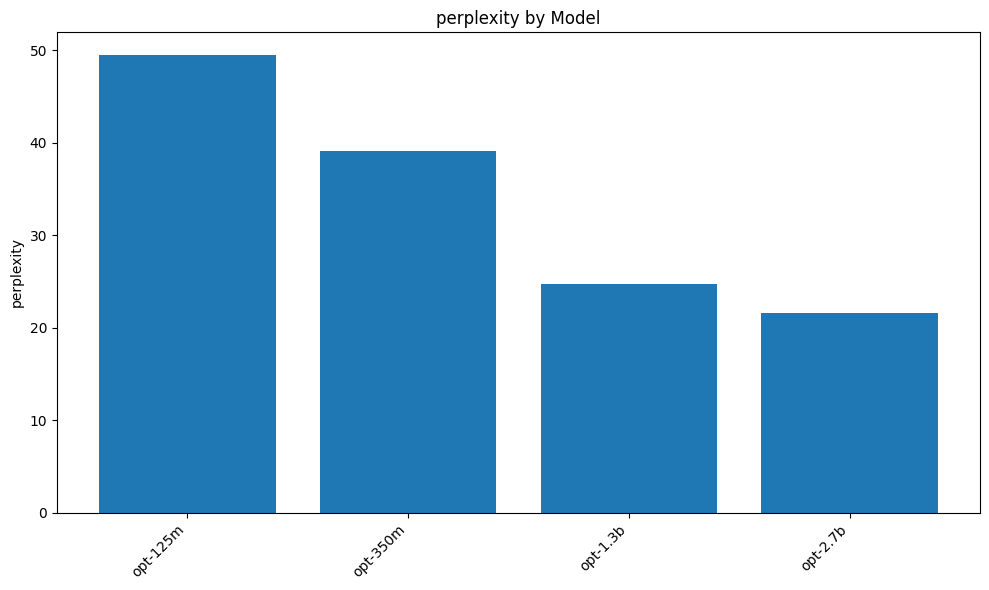

In [ ]:
from typing import Dict, List, Any
import matplotlib.pyplot as plt
import json
import os


class PlotResultsService:
    """
    Service class for plotting and saving evaluation results for LLM metrics.
    """

    @staticmethod
    def plot_results(results: Dict[str, List[Any]]) -> None:
        """
        Create bar plots comparing results across models for each metric found in the results.
        Stores the results in separate JSON files per metric.

        Args:
            results (dict): Dictionary with model IDs as keys and a list of MetricResult objects as values.
        """
        if not results:
            raise ValueError("No results provided to plot_results.")

        # Prepare output directory
        os.makedirs("results", exist_ok=True)

        # Collect all metric names present in the results
        metric_names = set()
        for metric_results in results.values():
            if isinstance(metric_results, list):
                for metric_result in metric_results:
                    if hasattr(metric_result, "name"):
                        metric_names.add(metric_result.name)

        if not metric_names:
            raise ValueError(
                "No metric names found in results. Ensure results contain MetricResult objects with a 'name' attribute."
            )

        # For each metric, collect values for all models and plot
        for metric_name in metric_names:
            filtered_results = {}
            models = []
            values = []

            for model_id, metric_results in results.items():
                # Defensive: ensure metric_results is a list and not empty
                if not isinstance(metric_results, list) or not metric_results:
                    continue  # skip models with no results

                # Find the MetricResult for the current metric_name
                metric_value = None
                for metric_result in metric_results:
                    if hasattr(metric_result, "name") and hasattr(
                        metric_result, "result"
                    ):
                        if metric_result.name == metric_name:
                            metric_value = metric_result.result
                            break
                if metric_value is None:
                    continue  # skip if this metric is not present for this model

                filtered_results[model_id] = metric_value
                model_name = model_id.split("/")[-1]
                models.append(model_name)
                values.append(metric_value)

            if not filtered_results:
                continue  # nothing to plot for this metric

            # Save filtered results to JSON
            results_file = f"results/{metric_name}_results.json"
            with open(results_file, "w") as f:
                json.dump(filtered_results, f, indent=4)

            # Create bar plot
            plt.figure(figsize=(10, 6))
            plt.bar(models, values)
            plt.title(f"{metric_name} by Model")
            plt.xticks(rotation=45, ha="right")
            plt.ylabel(metric_name)
            plt.tight_layout()
            plt.show()


# For backward compatibility, provide a function interface
def plot_results(results: Dict[str, List[Any]]) -> None:
    """
    Wrapper function to use PlotResultsService for plotting results.
    """
    PlotResultsService.plot_results(results)

## 3. Measure LLM efficiency

We recommend to checkout the [Pruna documentation](https://docs.pruna.ai/en/stable/docs_pruna/user_manual/evaluation.html) for access to AI efficiency functions.

**Implementation task:**
- Implement the `evaluate_models` function that takes a list of models and a list of metrics and returns a dictionary with the model/metric evaluation results. We recommend to use the `EvaluationAgent` from Pruna for efficent development of the function.

In [ ]:
def evaluate_models(model_ids, metrics, dataset="WikiText"):
    """
    Evaluate multiple models using the specified metrics.

    Args:
        model_ids (list): List of model IDs to evaluate
        metrics (list): List of metric instances to compute

    Returns:
        dict: Dictionary mapping model IDs to their evaluation results
    """
    results = {}

    ### To Complete ###
    for model_id in model_ids:
        print(f"\nEvaluating {model_id}")
        try:
            # Load model and tokenizer
            model = AutoModelForCausalLM.from_pretrained(
                model_id, torch_dtype="auto"
            ).cuda()
            tokenizer = AutoTokenizer.from_pretrained(model_id)
            device = metrics[0].device
            # Create task and evaluation agent
            eval_agent = EvaluationAgent(
                request=metrics, 
                datamodule=PrunaDataModule.from_string(dataset, tokenizer=tokenizer), 
                device=device
            )
            model_results = eval_agent.evaluate(model)
            results[model_id] = model_results
            print(model_results)

            # Cleanup
            del model
            del tokenizer
            torch.cuda.empty_cache()
            gc.collect()

        except Exception as e:
            print(f"Error evaluating {model_id}: {str(e)}")
    ### End of To Complete ###

    return results

### 3.1 Evaluate LLM Quality

Quality evaluation is a very important step when working with LLMs. It helps to know the model's capabilities and limits. However, it is also very complex since it highly depends on the final application (e.g. dataset, task). For this tutorial, we will focus on the [perplexity metric](https://en.wikipedia.org/wiki/Perplexity) which measures the average token negative log-likelihood of a dataset given a model.

**Implementation task:**
- Benchmark the LLMs with the perplexity metric.
- Plot the results.

**Questions:**
- What is the the type of model with the best perplexity?
- What is the size of the model with the best perplexity?
- When is the perplexity metric useful?
- What are the limits of the perplexity metric to show the model performance?

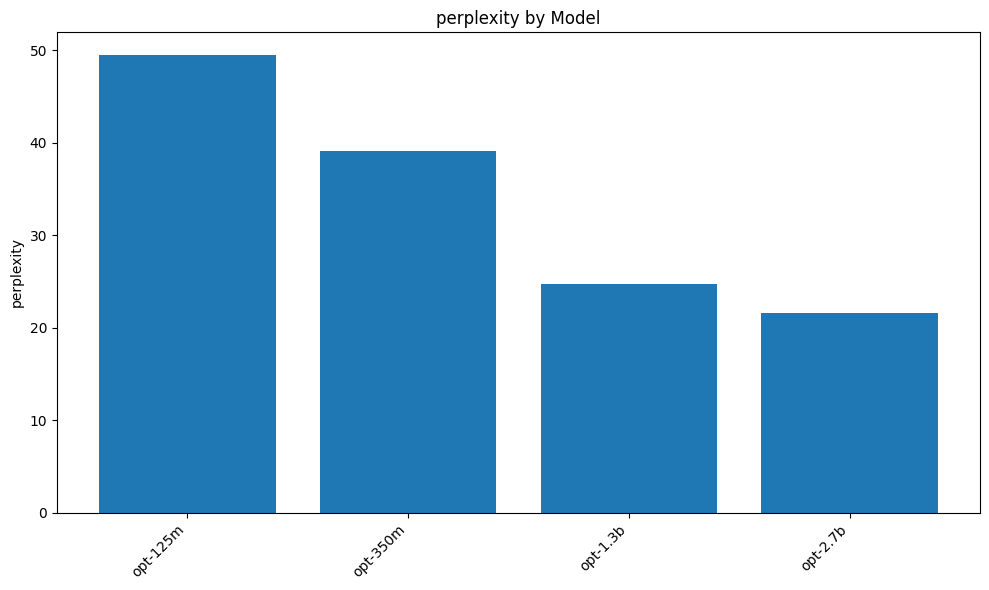

In [ ]:
### To Complete ###
metrics = [TorchMetricWrapper(metric_name="perplexity", call_type="single")]
results_perplexity = evaluate_models(model_ids, metrics, dataset="WikiText")
plot_results(results_perplexity)
### End of To Complete ###

### 3.2 Evaluate LLM memory

**Implementation task:**
- Benchmark the LLMs with the disk, inference, and training GPU memory metric.
- Plot the results.

**Questions:**
- What is the the type of model with the lowest GPU memory consumption?
- What is the the size of model with the lowest GPU memory consumption?
- When is the GPU memory metric useful?
- What are the limits of the GPU memory metric to show the model performance?

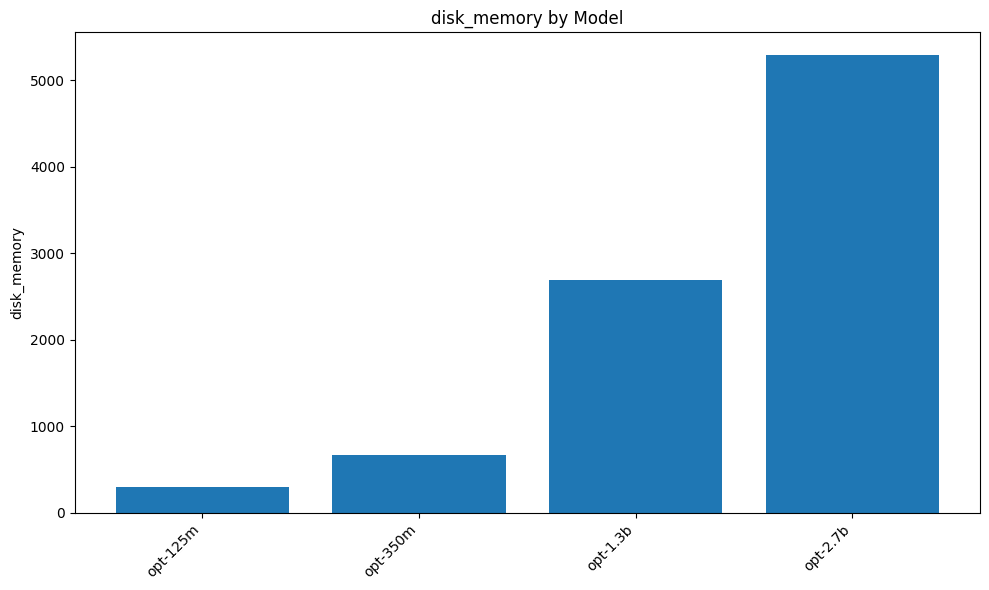

In [ ]:
# ### To Complete ###
metrics = [
    DiskMemoryMetric(),
    # InferenceMemoryMetric(),
    # TrainingMemoryMetric(),
]

results_memory = evaluate_models(model_ids, metrics, dataset="WikiText")
plot_results(results_memory)
# ### End of To Complete ###

### 3.3 Evaluate LLM compute

**Implementation task:**
- Benchmark the LLMs with the MAC metric.
- Plot the results.

**Questions:**
- What is the the type of model with the lowest MAC?
- What is the the size of model with the lowest MAC?
- When is the MAC metric useful?
- What are the limits of the MAC metric?

INFO - Using best available device: 'cuda'
INFO - Using best available device: 'cuda'



Evaluating facebook/opt-125m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


[MetricResult(name='total_macs', params={'device': 'cuda', 'module_macs': {'OPTForCausalLM': 22375283712.0}, 'module_params': {'OPTForCausalLM': 123664896.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7e5c9b432540>}, result=22375283712.0), MetricResult(name='total_params', params={'device': 'cuda', 'module_macs': {'OPTForCausalLM': 22375283712.0}, 'module_params': {'OPTForCausalLM': 123664896.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7e5c9b432540>}, result=123664896.0)]

Evaluating facebook/opt-350m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


[MetricResult(name='total_macs', params={'device': 'cuda', 'module_macs': {'OPTForCausalLM': 59544354816.0}, 'module_params': {'OPTForCausalLM': 329097216.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7e5c9b432540>}, result=59544354816.0), MetricResult(name='total_params', params={'device': 'cuda', 'module_macs': {'OPTForCausalLM': 59544354816.0}, 'module_params': {'OPTForCausalLM': 329097216.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7e5c9b432540>}, result=329097216.0)]

Evaluating facebook/opt-1.3b


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


[MetricResult(name='total_macs', params={'device': 'cuda', 'module_macs': {'OPTForCausalLM': 237348560896.0}, 'module_params': {'OPTForCausalLM': 1311559680.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7e5c9b432540>}, result=237348560896.0), MetricResult(name='total_params', params={'device': 'cuda', 'module_macs': {'OPTForCausalLM': 237348560896.0}, 'module_params': {'OPTForCausalLM': 1311559680.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7e5c9b432540>}, result=1311559680.0)]

Evaluating facebook/opt-2.7b


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


[MetricResult(name='total_macs', params={'device': 'cuda', 'module_macs': {'OPTForCausalLM': 478915921920.0}, 'module_params': {'OPTForCausalLM': 2646348800.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7e5c9b432540>}, result=478915921920.0), MetricResult(name='total_params', params={'device': 'cuda', 'module_macs': {'OPTForCausalLM': 478915921920.0}, 'module_params': {'OPTForCausalLM': 2646348800.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7e5c9b432540>}, result=2646348800.0)]


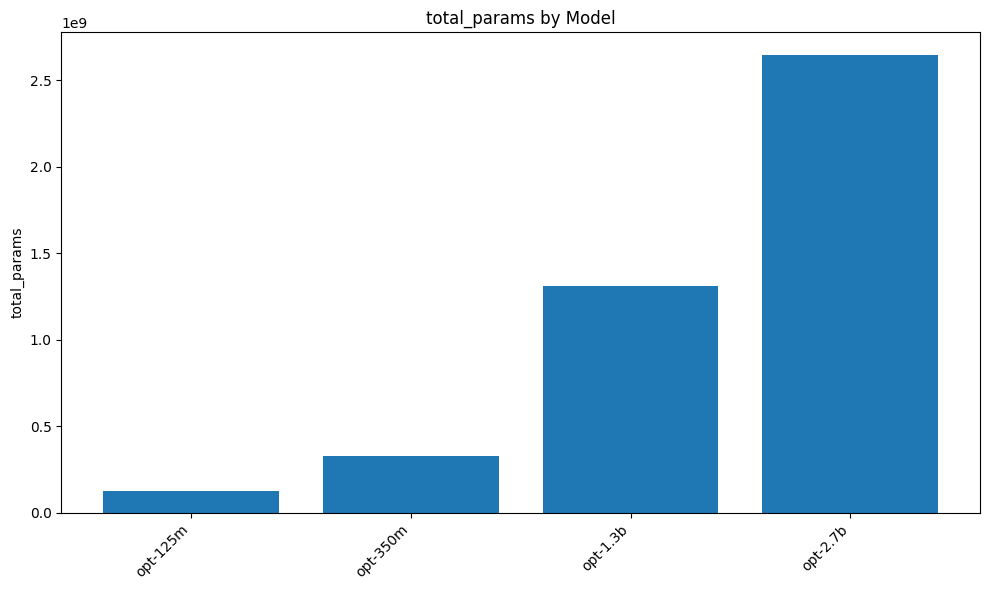

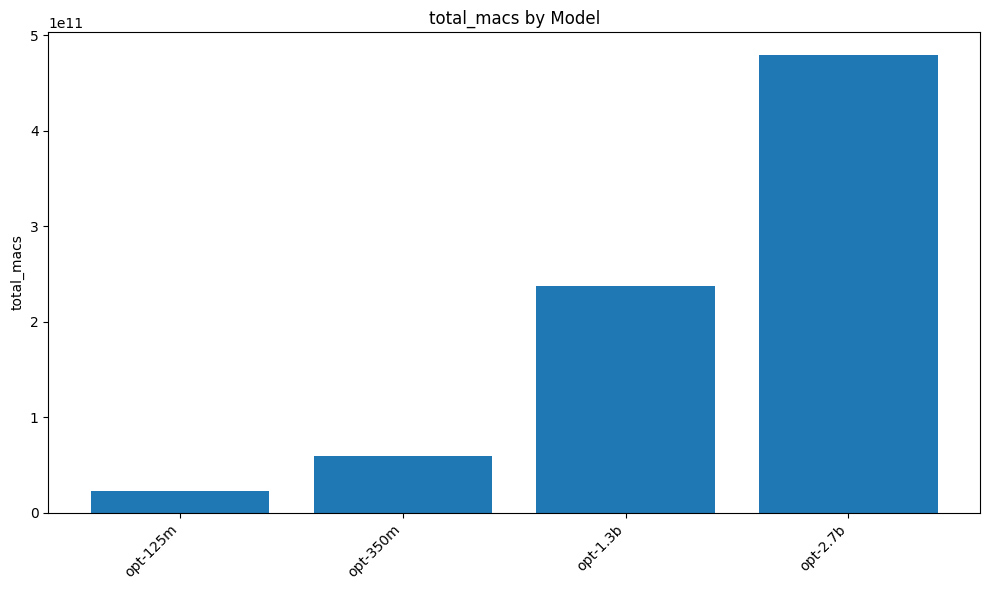

In [23]:
### To Complete ###
metrics = [
    TotalMACsMetric(),
    TotalParamsMetric(),
]

results_mac = evaluate_models(model_ids, metrics, dataset="WikiText")
plot_results(results_mac)
### End of To Complete ###

### 3.4 Evaluate LLM latency

**Implementation task:**
- Benchmark the LLMs with the latency metric.
- Plot the results.

**Questions:**
- What is the the type of model with the lowest latency?
- What is the the size of model with the lowest latency?
- When is the latency metric useful?
- What are the limits of the latency metric?


Evaluating facebook/opt-125m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


[MetricResult(name='total_time', params={'n_iterations': 100, 'n_warmup_iterations': 10, 'device': 'cuda', 'timing_type': 'sync', 'batch_size': 1}, result=713.4278388023376)]

Evaluating facebook/opt-350m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


[MetricResult(name='total_time', params={'n_iterations': 100, 'n_warmup_iterations': 10, 'device': 'cuda', 'timing_type': 'sync', 'batch_size': 1}, result=1304.7423372268677)]

Evaluating facebook/opt-1.3b


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


[MetricResult(name='total_time', params={'n_iterations': 100, 'n_warmup_iterations': 10, 'device': 'cuda', 'timing_type': 'sync', 'batch_size': 1}, result=2462.540219306946)]

Evaluating facebook/opt-2.7b


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


[MetricResult(name='total_time', params={'n_iterations': 100, 'n_warmup_iterations': 10, 'device': 'cuda', 'timing_type': 'sync', 'batch_size': 1}, result=5018.488754272461)]


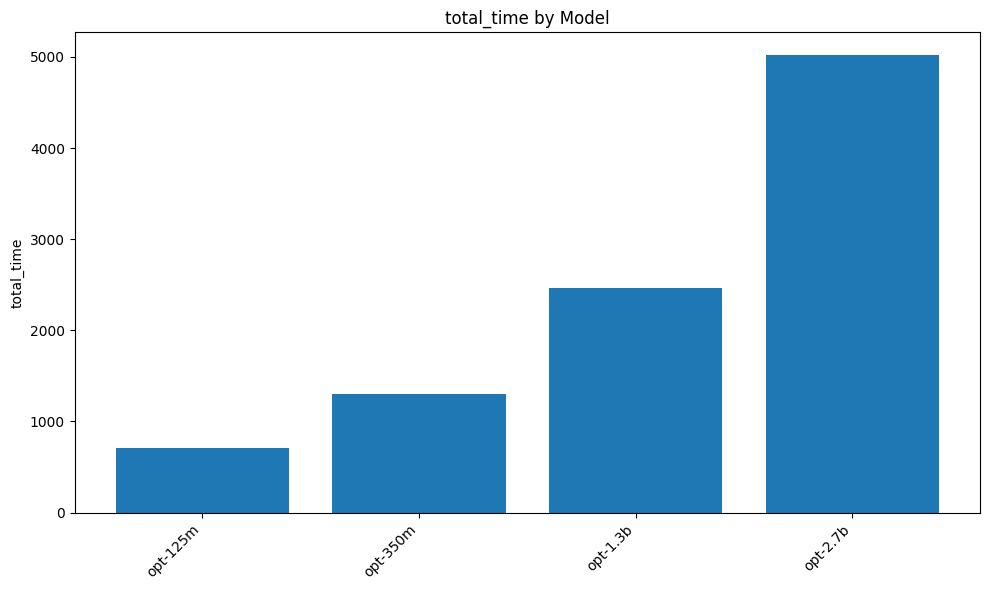

In [24]:
### To Complete ###
metrics = [
    TotalTimeMetric(
        n_iterations=100,
        n_warmup_iterations=10,
        device="cuda",
        timing_type="sync",
    ),
]

results_latency = evaluate_models(model_ids, metrics, dataset="WikiText")
plot_results(results_latency)
### End of To Complete ###

### 3.5 Evaluate LLM energy consumption

**Implementation task:**
- Benchmark the LLMs with the energy metric.
- Plot the results.

**Questions:**
- What is the the type of model with the lowest energy consumption?
- What is the the size of model with the lowest energy consumption?
- When is the energy metric useful?
- What are the limits of the energy metric?


Evaluating facebook/opt-125m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.
[codecarbon WARNING @ 11:02:57] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 11:02:57] [setup] RAM Tracking...
[codecarbon INFO @ 11:02:57] [setup] CPU Tracking...
[codecarbon WARNING @ 11:02:58] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at

[MetricResult(name='energy_consumed', params={'n_iterations': 100, 'n_warmup_iterations': 10, 'device': 'cuda'}, result=5.124590995389076e-05)]

Evaluating facebook/opt-350m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.
[codecarbon WARNING @ 11:03:05] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 11:03:05] [setup] RAM Tracking...
[codecarbon INFO @ 11:03:05] [setup] CPU Tracking...
[codecarbon WARNING @ 11:03:05] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at

[MetricResult(name='energy_consumed', params={'n_iterations': 100, 'n_warmup_iterations': 10, 'device': 'cuda'}, result=7.551234941100487e-05)]

Evaluating facebook/opt-1.3b


...

[MetricResult(name='energy_consumed', params={'n_iterations': 100, 'n_warmup_iterations': 10, 'device': 'cuda'}, result=0.00013494100521186013)]

Evaluating facebook/opt-2.7b


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.
[codecarbon WARNING @ 11:03:44] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 11:03:44] [setup] RAM Tracking...
[codecarbon INFO @ 11:03:44] [setup] CPU Tracking...
[codecarbon WARNING @ 11:03:45] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[codecarbon WARNING @ 11:03:47] Background scheduler didn't run for a long period (2s), results might be inaccurate
[codecarbon INFO @ 11:03:47] Energy consumed for RAM : 0.000013 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 11:03:48] Delta energy consumed for CPU with cpu_load : 0.000013 kWh, power : 21.051526062000004 W
[codecarbon INFO @ 11:03:48] Energy consumed for All CPU : 0.000013 kWh
[codecarbon INFO @ 11:03:48] Energy consumed for all GPUs : 0.000022 kWh. Total GPU Power : 27.96745390597656 W
[codecarbon INFO @ 11:03:48] 0.000048 kWh of electricity used since the beginning.
[codecarbon WARNING @ 11:03:55] Background scheduler didn't run for a long period (6s), results might be inaccurate
[codecarbon INFO @ 11:03:55] Energy consumed for RAM : 0.000048 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 11:03:55] Delta energy consumed for CPU with cpu_load : 0.000037 kWh, power : 21.314743104000005 W
[codecarbon INFO @ 11:03:55] Energy consumed for All CPU : 0.000051 kWh
[codecarbon INFO 

[MetricResult(name='energy_consumed', params={'n_iterations': 100, 'n_warmup_iterations': 10, 'device': 'cuda'}, result=0.0002437262910557845)]


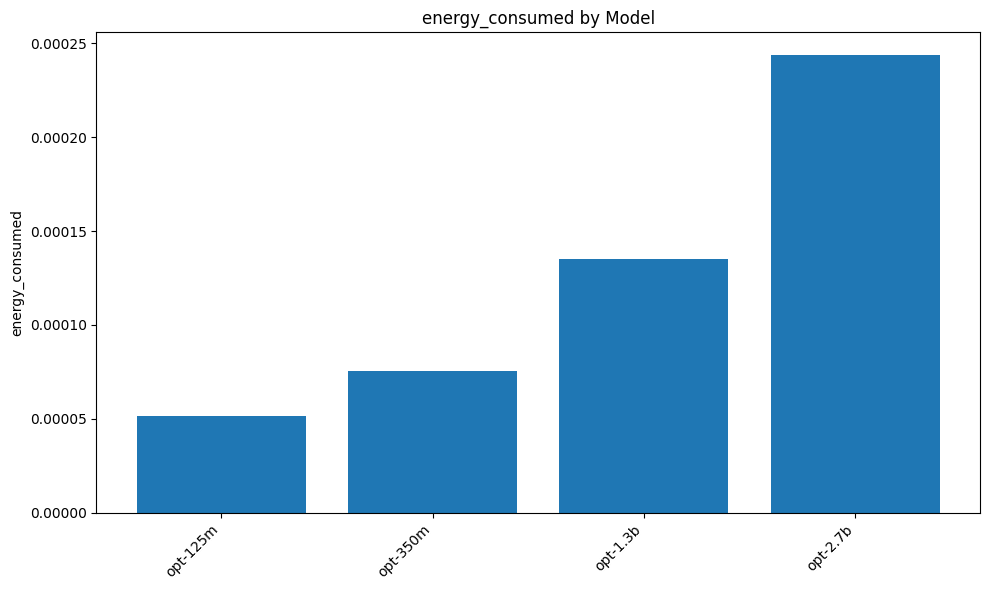

In [26]:
### To Complete ###
metrics = [
    EnergyConsumedMetric(
        n_iterations=100,
        n_warmup_iterations=10,
        device="cuda",
    ),
]

results_energy = evaluate_models(model_ids, metrics, dataset="WikiText")
plot_results(results_energy)
### End of To Complete ###

### 3.6 Compare LLM on a pareto front

**Implementation task:**
- Plot the results of the previous metrics in a pareto front. You can use the files containing the saved results when evaluating the previous metrics.

**Questions:**
- What is the best model on the pareto front?

In [51]:
def plot_pareto_front(metric1_results, metric2_results, metric1_name, metric2_name):
    """
    Plot pareto front comparing two metrics across models.

    Args:
        metric1_results: Results dictionary for first metric
        metric2_results: Results dictionary for second metric
        metric1_name: Name of first metric to display
        metric2_name: Name of second metric to display
    """
    # Extract values for each model
    models = []
    metric1_values = []
    metric2_values = []

    for model_name in metric1_results.keys():
        if model_name in metric1_results and model_name in metric2_results:
            models.append(model_name)
            metric1_values.append(
                [
                    metric
                    for metric in metric1_results[model_name]
                    if metric.name == metric1_name
                ][0].result
            )
            metric2_values.append(
                [
                    metric
                    for metric in metric2_results[model_name]
                    if metric.name == metric2_name
                ][0].result
            )
        else:
            print(f"{model_name} missed evaluation.")

    # Create scatter plot
    plt.figure(figsize=(10, 6))
    print(metric2_values)
    plt.scatter(metric1_values, metric2_values)

    # Add labels for each point
    for i, model in enumerate(models):
        plt.annotate(model, (metric1_values[i], metric2_values[i]))

    plt.xlabel(metric1_name)
    plt.ylabel(metric2_name)
    plt.title(f"Pareto Front: {metric1_name} vs {metric2_name}")
    plt.grid(True)
    plt.show()

[713.4278388023376, 1304.7423372268677, 2462.540219306946, 5018.488754272461]


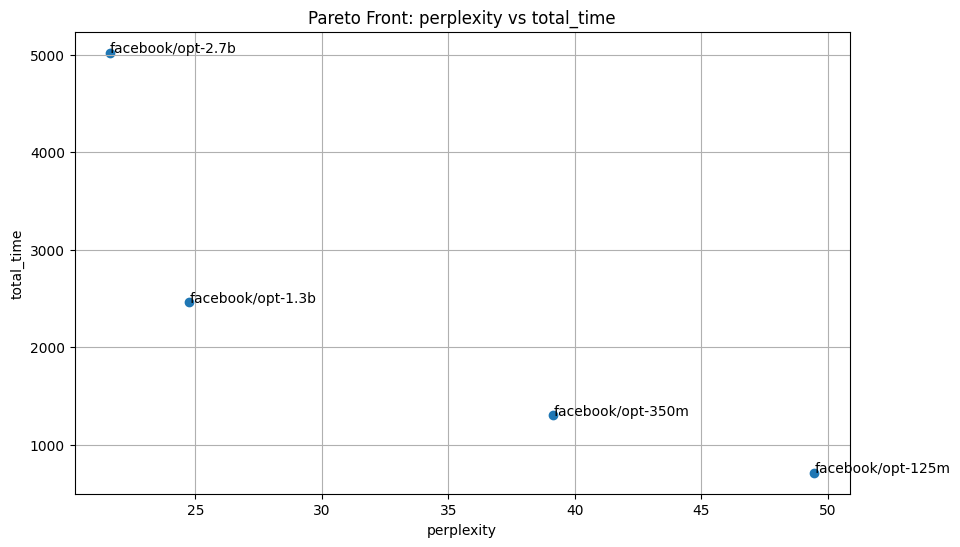

[300.0, 670.0, 2694.0, 5292.0]


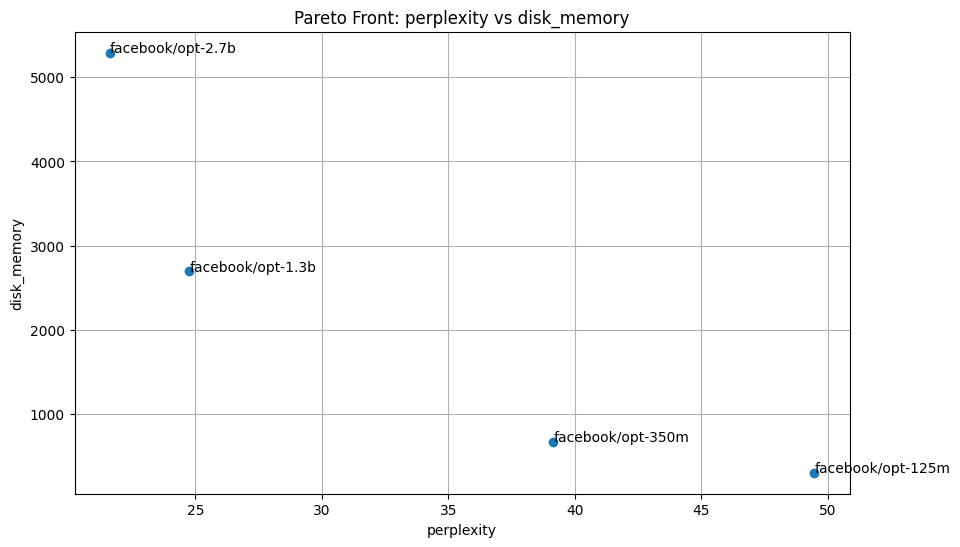

[22375283712.0, 59544354816.0, 237348560896.0, 478915921920.0]


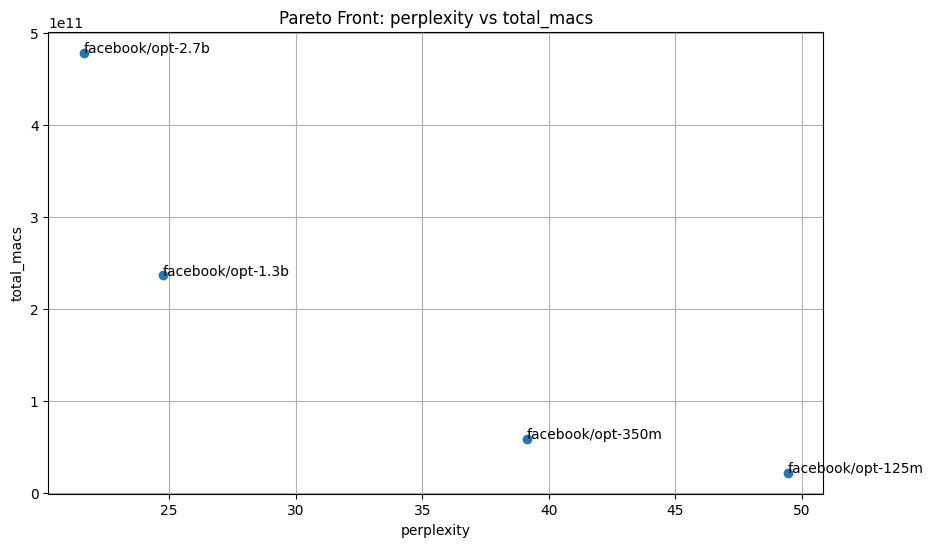

[123664896.0, 329097216.0, 1311559680.0, 2646348800.0]


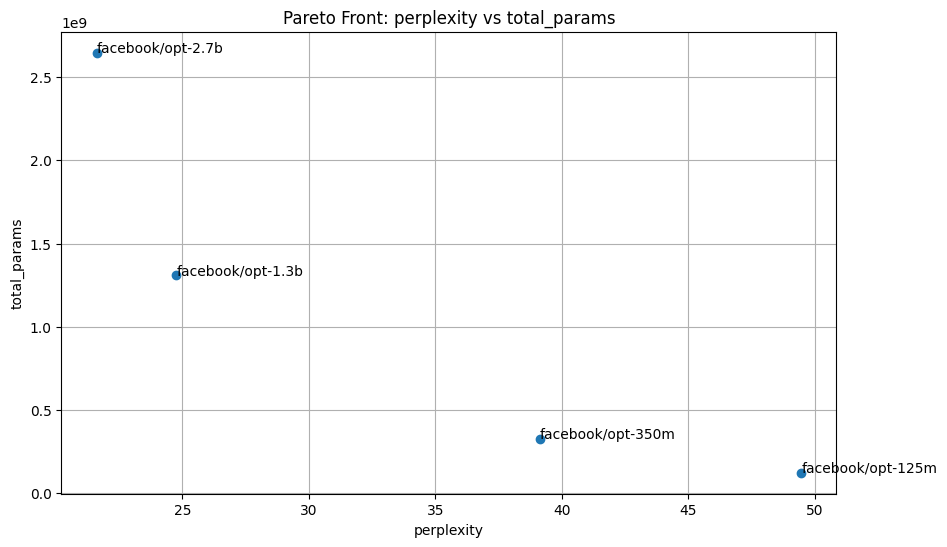

[5.124590995389076e-05, 7.551234941100487e-05, 0.00013494100521186013, 0.0002437262910557845]


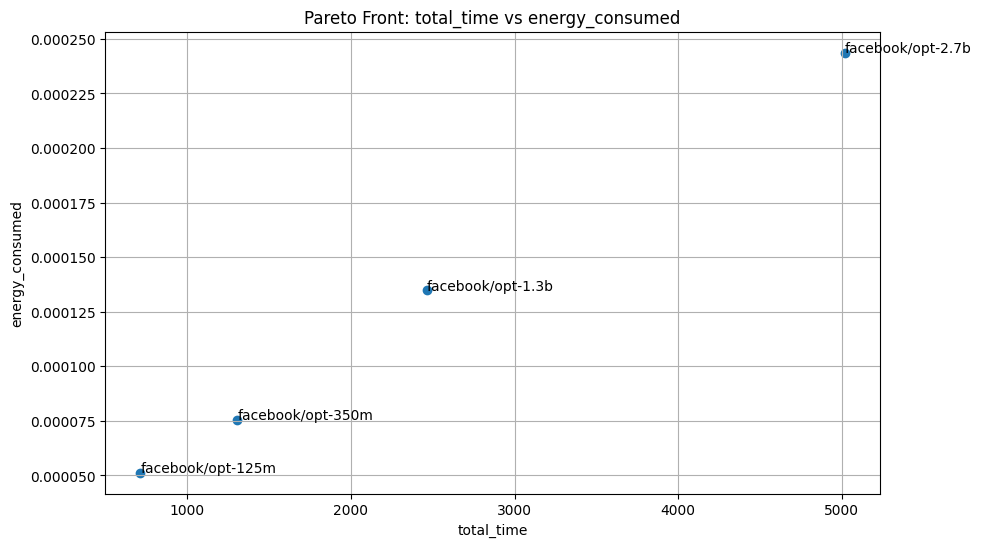

[22375283712.0, 59544354816.0, 237348560896.0, 478915921920.0]


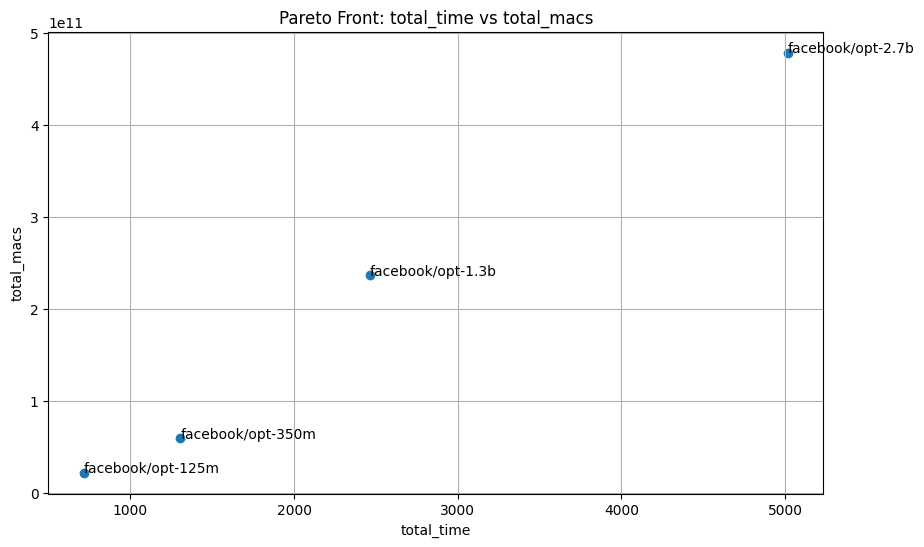

In [52]:
plot_pareto_front(results_perplexity, results_latency, "perplexity", "total_time")
plot_pareto_front(results_perplexity, results_memory, "perplexity", "disk_memory")
plot_pareto_front(results_perplexity, results_mac, "perplexity", "total_macs")
plot_pareto_front(results_perplexity, results_mac, "perplexity", "total_params")
plot_pareto_front(results_latency, results_energy, "total_time", "energy_consumed")
plot_pareto_front(results_latency, results_mac, "total_time", "total_macs")

## 4. Bonus: Evaluate the quality and efficiency with different context lengths